# Introduction

This sample case study was provided through the Google Data Analytics Professional Certificate course.

### Valuable things I learned while working with this data:
* Data tables vs. data frames - more efficient functions and data table notation resembles SQL Selects.
* Data permaneance - learning to make sure that any transformations made didn't cause any unintended consequences.
* Date formats - learning to work with POSIX functions as well as transforming dates into strings to be read more easily by Excel and Tableau.

### Data Limitations:
* Unless the FitBit was worn all day (usually not the case), the daily data will be at least slightly skewed.
* Our sleep data only had 24 users, most of whom recorded their sleep on less than 30 days (Kept it in the analysis for practice/demonstration purposes).
* We had to completely scrap our weight data which only had 13 users, only 3 of which logged their weight more than 4 times.
* We did not have age, gender, height, or weight data, all of which are extremely deterministic when it comes to health and activity.
* One of the metrics we used the most was active minute intensity (lightly, fairly, and very). When measured against the American Heart Association's recommendation of 150 weekly active minutes, every user went way beyond, leading us to question FitBit's definition of active minute intensity.

# 1. Ask

### Scenario
You are a junior data analyst working on the marketing analyst team at Bellabeat, a high-tech manufacturer of health-focused products for women. Bellabeat is a successful small company, but they have the potential to become a larger player in the global smart device market. Urška Sršen, cofounder and Chief Creative Officer of Bellabeat, believes that analyzing smart device fitness data could help unlock new growth opporunities for the company. You have been asked to focus on one of Bellabeat’s products and analyze smart device data to gain insight into how consumers are using their smart devices. The insights you discover will then help guide marketing strategy for the company. You will present your analysis to the Bellabeat executive team along with your high-level recommendations for Bellabeat’s marketing strategy.

Urška Sršen and Sando Mur founded Bellabeat, a high-tech company that manufactures health-focused smart products. Sršen used her background as an artist to develop beautifully designed technology that informs and inspires women around the world. Collecting data on activity, sleep, stress, and reproductive health has allowed Bellabeat to empower women with knowledge about their own health and habits. Since it was founded in 2013, Bellabeat has grown rapidly and quickly positioned itself as a tech-driven wellness company for women.

By 2016, Bellabeat had opened offices around the world and launched multiple products. Bellabeat products became available through a growing number of online retailers in addition to their own e-commerce channel on their website. The company has invested in traditional advertising media, such as radio, out-of-home billboards, print, and television, but focuses on digital marketing extensively. Bellabeat invests year-round in Google Search, maintaining active Facebook and Instagram pages, and consistently engages consumers on Twitter. Additionally, Bellabeat runs video ads on Youtube and display ads on the Google Display Network to support campaigns around key marketing dates.

Sršen asks you to analyze smart device usage data in order to gain insight into how consumers use non-Bellabeat smart devices.

### These questions will guide your analysis:
1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat marketing strategy?

# 2. Prepare
## Data Collection

We will be using the following data: [FitBit Fitness Tracker Data](https://www.kaggle.com/datasets/arashnic/fitbit) (CC0: Public Domain, dataset made available through [Mobius](https://www.kaggle.com/arashnic)): This Kaggle data set contains personal fitness tracker from from 3/12/2016 - 5/12/2016. Fitbit users consented to the submission of personal tracker data. It includes information about daily activity that can be used to explore users’ habits.

### Environment Set-Up

In [75]:
# Load the packages
library(tidyverse)
library(janitor)
library(data.table)
library(tools)

In [76]:
# Import the data into a list of data tables
path <- "/kaggle/input/fitbit/mturkfitbit_export_3.12.16-4.11.16"
csv_files <- list.files(path = path,
                        pattern = "*.csv$",
                        recursive = TRUE,
                        full.names = TRUE)
unclean_data_tables1 <- map(csv_files, fread) %>% 
  set_names(file_path_sans_ext(basename(csv_files)))

path <- "/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16"
csv_files <- list.files(path = path,
                        pattern = "*.csv$",
                        recursive = TRUE,
                        full.names = TRUE)
unclean_data_tables2 <- map(csv_files, fread) %>% 
  set_names(file_path_sans_ext(basename(csv_files)))

# 3. Process
## Data Cleaning
#### There is a lot of data in 29 total data tables, so our first step will be to simply remove any data tables aren't of use to us. The minute tables are far too granular, so we can get rid of those.

In [77]:
# We'll use the more efficient negative indices rather than searching for substrings
unclean_data_tables1 <- unclean_data_tables1[-c(6:10)]
unclean_data_tables2 <- unclean_data_tables2[-c(9:16)]

#### Now that we have 2 lists of the same data (except for sleep data) from different time periods, we can combine based on their shared column names.

In [78]:
# Get all unique names from both lists
table_names <- unique(c(names(unclean_data_tables1), names(unclean_data_tables2)))

# Combine the lists
unclean_data_tables <- lapply(table_names, function(name) {
  if (name %in% names(unclean_data_tables1) && name %in% names(unclean_data_tables2)) {
    # If the table is in both lists, join on matching column names
    rbindlist(list(unclean_data_tables1[[name]], unclean_data_tables2[[name]]), use.names = TRUE, fill = TRUE)
  } else {
    # If the table is only in one of the lists (like "sleepDay_merged"), use it as is
    unclean_data_tables2[[name]]
  }
})

# Name the elements of the combined list
names(unclean_data_tables) <- table_names

#### Now that we have a single list of data tables, we can clean the individual tables and further explore.

In [79]:
# Clean the column names for consistency by converting to snake case
dt_list <- lapply(unclean_data_tables, clean_names)

# Remove any instance of "total" in column names as total is implied and change "step" to "steps"
dt_list <- lapply(dt_list, function(dt) {
  setnames(dt, names(dt), gsub("^total_|_total$|_total_", "", names(dt)))
  setnames(dt, names(dt), gsub("^step$", "steps", names(dt)))
})

# We need to create consistent date column names for a merge - this is easy because every date column is the second column
lapply(dt_list, function(dt) {
  setnames(dt, 2, "date", skip_absent = TRUE)
})

id,date,steps,distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories
<int64>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1503960366,3/25/2016,11004,7.11,7.11,0,2.57,0.46,4.07,0.00,33,12,205,804,1819
1503960366,3/26/2016,17609,11.55,11.55,0,6.92,0.73,3.91,0.00,89,17,274,588,2154
1503960366,3/27/2016,12736,8.53,8.53,0,4.66,0.16,3.71,0.00,56,5,268,605,1944
1503960366,3/28/2016,13231,8.93,8.93,0,3.19,0.79,4.95,0.00,39,20,224,1080,1932
1503960366,3/29/2016,12041,7.85,7.85,0,2.16,1.09,4.61,0.00,28,28,243,763,1886
1503960366,3/30/2016,10970,7.16,7.16,0,2.36,0.51,4.29,0.00,30,13,223,1174,1820
1503960366,3/31/2016,12256,7.86,7.86,0,2.29,0.49,5.04,0.00,33,12,239,820,1889
1503960366,4/1/2016,12262,7.87,7.87,0,3.32,0.83,3.64,0.00,47,21,200,866,1868
1503960366,4/2/2016,11248,7.25,7.25,0,3.00,0.45,3.74,0.00,40,11,244,636,1843


In [80]:
# Now we can see how many unique users and days logged each data table has to ensure we have a large enough sample size
lapply(dt_list, function(dt) {
  dt[, .(unique_dates = uniqueN(date)), by = id]
})

id,unique_dates
<int64>,<int>
1503960366,49
1624580081,49
1644430081,40
1844505072,42
1927972279,42
2022484408,42
2026352035,42
2320127002,42
2347167796,32


#### All of the data tables have at least 30 unique users (desired minimum sample size) besides heart rate, sleep, and weight. Sleep is close at 24, so we'll keep it in for practice. Heart rate and weight are exceptionally low, so we'll exclude those from our analysis.

In [81]:
dt_list <- dt_list[-c(2, 6)]

#### Next, we'll perform some checks.

In [82]:
# Check for duplicate rows
lapply(dt_list, function(dt) {
  sum(duplicated(dt) | duplicated(dt, fromLast = TRUE))
})

# Remove duplicate rows
dt_list <- lapply(dt_list, unique)

# Check for NA values
lapply(dt_list, function(dt) {
  colSums(is.na(dt))
})

# No NA values

$dailyActivity_merged
[1] 0

$hourlyCalories_merged
[1] 350

$hourlyIntensities_merged
[1] 350

$hourlySteps_merged
[1] 350

$dailyCalories_merged
[1] 0

$dailyIntensities_merged
[1] 0

$dailySteps_merged
[1] 0

$sleepDay_merged
[1] 6

$dailyActivity_merged
                        id                       date 
                         0                          0 
                     steps                   distance 
                         0                          0 
          tracker_distance logged_activities_distance 
                         0                          0 
      very_active_distance moderately_active_distance 
                         0                          0 
     light_active_distance  sedentary_active_distance 
                         0                          0 
       very_active_minutes      fairly_active_minutes 
                         0                          0 
    lightly_active_minutes          sedentary_minutes 
                         0                          0 
                  calories 
                         0 

$hourlyCalories_merged
      id     date calories 
       0        0        0 

$hourlyIntensities_merged
               id              date         intensity average_intensity 
                0                 0                 0                 0 

$hourlySteps_merged
   id  date steps 
    0     0     0 

$dailyCalories_merged
      id     date calories 
       0        0        0 

$dailyIntensities_merged
                        id                       date 
                         0                          0 
         sedentary_minutes     lightly_active_minutes 
                         0                          0 
     fairly_active_minutes        very_active_minutes 
                         0                          0 
 sedentary_active_distance      light_active_distance 
                         0                          0 
moderately_active_distance       very_active_distance 
                         0                          0 

$dailySteps_merged
   id  date steps 
    0     0     0 

$sleepDay_merged
            id           date  sleep_records minutes_asleep    time_in_bed 
             0              0              0              0              0

#### The daily activity table already contains information about calories, intensities, and steps. We need to check to see if it'those individual tables are redundant.

In [83]:
# Helper function
compare_tables <- function(dt_list, x_index, y_index, match_cols) {
  
  # Count the total rows in the smaller data table
  total_rows_y <- nrow(dt_list[[y_index]])
  
  # Find the matching rows and calculate the percentage of the smaller data table that matches 
  matching_rows <- dt_list[[x_index]][dt_list[[y_index]], on = match_cols, nomatch = 0L]
  num_matching_rows <- nrow(matching_rows)
  percentage <- (num_matching_rows / total_rows_y) * 100
  
  list(
    total_rows_y = total_rows_y,
    matching_rows = num_matching_rows,
    percentage = percentage
  )
}

# Compare the tables
compare_tables(dt_list, 1, 5, c("id", "date", "calories"))
compare_tables(dt_list, 1, 6, c("id", "date", c(names(dt_list$dailyIntensities_merged))))
compare_tables(dt_list, 1, 7, c("id", "date", "steps"))

$total_rows_y
[1] 940

$matching_rows
[1] 940

$percentage
[1] 100

$total_rows_y
[1] 940

$matching_rows
[1] 940

$percentage
[1] 100

$total_rows_y
[1] 940

$matching_rows
[1] 940

$percentage
[1] 100

In [84]:
# All of the data is redundant so we can remove those tables
dt_list <- dt_list[-c(5:7)]

In [85]:
# The last step before merging is to convert dates to consistent formats. This will be easier by splitting the data table list into daily and hourly lists.
daily_list <- dt_list[c(1, 5)]
hourly_list <- dt_list[2:4]

daily_list <- lapply(daily_list, function(dt) {
  dt[, date := parse_date_time(date, orders = c("mdy", "mdy HMS p"))]
}) # We need the more flexible parse_date_time() function to handle multiple formats

hourly_list <- lapply(hourly_list, function(dt) {
  dt[, date := mdy_hms(date)]
})

In [86]:
# Now we can finally extract our daily and hourly data tables from the lists based on id and date
daily_activity <- Reduce(function(x, y) merge(x, y, all.x = TRUE, by = c("id", "date")), daily_list) # We want to use a left join here because we want the sleep data
hourly_activity <- Reduce(function(x, y) merge(x, y, all = TRUE, by = c("id", "date")), hourly_list) # We want an outer join here because all of the data is equally important for analysis

In [87]:
# Check our work
summary(daily_activity)
summary(hourly_activity)

       id                  date                            steps      
 Min.   :1503960366   Min.   :2016-03-12 00:00:00.00   Min.   :    0  
 1st Qu.:2320127002   1st Qu.:2016-04-09 00:00:00.00   1st Qu.: 3146  
 Median :4445114986   Median :2016-04-19 00:00:00.00   Median : 6999  
 Mean   :4781210221   Mean   :2016-04-19 01:26:35.13   Mean   : 7281  
 3rd Qu.:6962181067   3rd Qu.:2016-04-30 00:00:00.00   3rd Qu.:10544  
 Max.   :8877689391   Max.   :2016-05-12 00:00:00.00   Max.   :36019  
                                                                      
    distance      tracker_distance logged_activities_distance
 Min.   : 0.000   Min.   : 0.000   Min.   :0.0000            
 1st Qu.: 2.170   1st Qu.: 2.160   1st Qu.:0.0000            
 Median : 4.950   Median : 4.950   Median :0.0000            
 Mean   : 5.219   Mean   : 5.192   Mean   :0.1315            
 3rd Qu.: 7.500   3rd Qu.: 7.480   3rd Qu.:0.0000            
 Max.   :28.030   Max.   :28.030   Max.   :6.7271           

       id                  date                           calories     
 Min.   :1503960366   Min.   :2016-03-12 00:00:00.00   Min.   : 42.00  
 1st Qu.:2320127002   1st Qu.:2016-03-26 12:00:00.00   1st Qu.: 62.00  
 Median :4558609924   Median :2016-04-10 10:30:00.00   Median : 80.00  
 Mean   :4869940441   Mean   :2016-04-10 17:02:57.23   Mean   : 95.82  
 3rd Qu.:6962181067   3rd Qu.:2016-04-25 16:00:00.00   3rd Qu.:106.00  
 Max.   :8877689391   Max.   :2016-05-12 15:00:00.00   Max.   :948.00  
   intensity      average_intensity     steps        
 Min.   :  0.00   Min.   :0.00000   Min.   :    0.0  
 1st Qu.:  0.00   1st Qu.:0.00000   1st Qu.:    0.0  
 Median :  2.00   Median :0.03333   Median :   21.0  
 Mean   : 11.42   Mean   :0.19037   Mean   :  302.9  
 3rd Qu.: 15.00   3rd Qu.:0.25000   3rd Qu.:  323.0  
 Max.   :180.00   Max.   :3.00000   Max.   :10565.0  

In [88]:
# We know that steps and calories should probably not be zero or even close to zero, so let's remove any rows below 100 steps or 1000 calories as those were probably days that the wearable was not worn for the majority of the day.
daily_activity <- daily_activity[!(steps < 100 | calories < 1000)]

# 4. Analyze
## Data Transformation

### We'll create new columns for more granular analysis.

In [89]:
# Weekday, date, and hour columns
hourly_activity[, datetime := format(date, "%Y-%m-%d %H:%M:%S")] # Convert to string for easier parsing by Excel and Tableau
hourly_activity[, hour := hour(date)]
hourly_activity[, date := date(date)]
hourly_activity[, weekday := weekdays(date)]

daily_activity[, weekday := weekdays(date)]

# Make sure the days of the week are ordered correctly
weekday_order <- c("Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday")

hourly_activity$weekday <- factor(hourly_activity$weekday, levels = weekday_order)
daily_activity$weekday <- factor(daily_activity$weekday, levels = weekday_order)

# Percent of day tracked by dividing the total minutes tracked by a maximum 1440 minutes in a day
daily_activity[, percent_tracked := (very_active_minutes + fairly_active_minutes + lightly_active_minutes + sedentary_minutes) / 1440]

# Sleep quality score which is a percentage of total time in bed that the user is asleep
daily_activity$sleep_score <- daily_activity$minutes_asleep / daily_activity$time_in_bed

# Daily intensity score that takes into account all active minutes. The American Heart Association recommends 150 minutes of moderate intensity or 75 minutes of vigorous intensity per week. Therefore we'll assign .5 points for lightly active minutes, 1 points for fairly active minutes, and 2 points for very active minutes.
daily_activity$intensity_score <- daily_activity$very_active_minutes * 2 + daily_activity$fairly_active_minutes + daily_activity$lightly_active_minutes * 0.5

### We can create a classification of the day's activity level based on steps. We'll get our category ranges from the Tudor-Locke and Bassett classification system.

In [90]:
steps_breaks <- c(0, 5000, 7500, 10000, 12500, max(daily_activity[,steps]))
steps_labels <- c("Sedentary", "Physically Inactive", "Moderately Active", "Physically Active", "Very Active")

daily_activity[, daily_activity_category := cut(steps,
                                       breaks = steps_breaks,
                                       labels = steps_labels,
                                       include.lowest = TRUE)]

# Make sure that the categories are ordered correctly
daily_activity$daily_activity_category <- factor(daily_activity$daily_activity_category, levels = steps_labels)

### Next, we'll create new data tables with the averages of the metrics grouped by weekday, ID, and hour

In [91]:
# Create a list of column names that we want to average
numeric_avg_cols <- names(daily_activity)[sapply(daily_activity, is.numeric)]
numeric_avg_cols <- numeric_avg_cols[-1] # We don't need to find the averages of the ID column

# Grouped by weekday
weekday_avgs <- daily_activity[order(weekday), lapply(.SD, mean, na.rm = TRUE), by = weekday, .SDcols = numeric_avg_cols]

# Grouped by id
id_avgs <- daily_activity[, lapply(.SD, mean, na.rm = TRUE), by = id, .SDcols = numeric_avg_cols]

# Grouped by hour
hourly_avg_cols <- c("calories", "intensity", "steps")
hourly_avgs <- hourly_activity[, lapply(.SD, mean, na.rm = TRUE), by = hour, .SDcols = hourly_avg_cols]

In [92]:
# We can apply our steps categorization to users' average scores rather than their daily scores
id_avgs[, user_category := cut(steps,
                                       breaks = steps_breaks,
                                       labels = steps_labels,
                                       include.lowest = TRUE)]

# Make sure that the categories are ordered correctly
id_avgs$user_category <- factor(id_avgs$user_category, levels = steps_labels)

# Merge our user category with the activity tables
daily_activity <- merge(daily_activity, id_avgs[, .(id, user_category)], by = "id")
hourly_activity <- merge(hourly_activity, id_avgs[, .(id, user_category)], by = "id")

In [93]:
# Check that we didn't create any unwanted NA values (besides sleep data)
colSums(is.na(daily_activity))
colSums(is.na(hourly_activity))

id                       date 
                         0                          0 
                     steps                   distance 
                         0                          0 
          tracker_distance logged_activities_distance 
                         0                          0 
      very_active_distance moderately_active_distance 
                         0                          0 
     light_active_distance  sedentary_active_distance 
                         0                          0 
       very_active_minutes      fairly_active_minutes 
                         0                          0 
    lightly_active_minutes          sedentary_minutes 
                         0                          0 
                  calories              sleep_records 
                         0                        814 
            minutes_asleep                time_in_bed 
                       814                        814 
                   weekday            percent_tracked 
                         0                          0 
               sleep_score            intensity_score 
                       814                          0 
   daily_activity_category              user_category 
                         0                          0

id              date          calories         intensity 
                0                 0                 0                 0 
average_intensity             steps          datetime              hour 
                0                 0                 0                 0 
          weekday     user_category 
                0                 0

## Data Analysis

In [94]:
# Summary Statistics
summary(daily_activity[, .(steps,
                       very_active_minutes,
                       fairly_active_minutes,
                       lightly_active_minutes,
                       sedentary_minutes,
                       calories,
                       minutes_asleep,
                       time_in_bed,
                       percent_tracked,
                       sleep_score,
                       intensity_score,
                       user_category)])

     steps       very_active_minutes fairly_active_minutes
 Min.   :  108   Min.   :  0.00      Min.   :  0.00       
 1st Qu.: 4790   1st Qu.:  0.00      1st Qu.:  0.00       
 Median : 7891   Median :  6.00      Median :  8.00       
 Mean   : 8302   Mean   : 22.39      Mean   : 14.77       
 3rd Qu.:11100   3rd Qu.: 34.00      3rd Qu.: 21.00       
 Max.   :36019   Max.   :210.00      Max.   :143.00       
                                                          
 lightly_active_minutes sedentary_minutes    calories    minutes_asleep
 Min.   :  0.0          Min.   :  99.0    Min.   :1002   Min.   : 58   
 1st Qu.:147.0          1st Qu.: 724.0    1st Qu.:1878   1st Qu.:361   
 Median :212.0          Median :1018.0    Median :2225   Median :432   
 Mean   :211.5          Mean   : 958.6    Mean   :2378   Mean   :419   
 3rd Qu.:272.0          3rd Qu.:1188.0    3rd Qu.:2839   3rd Qu.:490   
 Max.   :720.0          Max.   :1440.0    Max.   :4900   Max.   :796   
                        

* Average steps is 8302, below the recommended amount of 10000, but well above the American average of 3000 - 4000 (according to the Mayo Clinic).
* Average intensity score is 167.6 which is far above the recommended amount of 22.
* Average sedentary time is 958 minutes or 15.97 hours per day, but the max is 1440 minutes, so we assume that sedentary time includes time in bed.
 * We unfortunately don't have enough sleep data to accurately determine how much of the sedentary minutes occurred while the user was awake.
* We can see that most users use their device for over 83%. 100% would be better, but we can still glean insight.
* Users sleep 419 minutes or just about 7 hours on average.
 * The National Sleep institute recommends 7-9 hours of sleep, so most users are hitting the minimum, which is better than over a third of Americans.
 * A WebMD survey (one of the few that distuingishes time asleep from time in bed) found that on average, Americans spend only 5.7 hours asleep while spending 7.67 hours in bed (our users' averages are 6.98 hours alsleep and 7.63 hours in bed).

In [95]:
summary(hourly_activity)

       id                  date               calories        intensity     
 Min.   :1503960366   Min.   :2016-03-12   Min.   : 42.00   Min.   :  0.00  
 1st Qu.:2320127002   1st Qu.:2016-03-26   1st Qu.: 62.00   1st Qu.:  0.00  
 Median :4558609924   Median :2016-04-10   Median : 80.00   Median :  2.00  
 Mean   :4869940441   Mean   :2016-04-10   Mean   : 95.82   Mean   : 11.42  
 3rd Qu.:6962181067   3rd Qu.:2016-04-25   3rd Qu.:106.00   3rd Qu.: 15.00  
 Max.   :8877689391   Max.   :2016-05-12   Max.   :948.00   Max.   :180.00  
                                                                            
 average_intensity     steps           datetime              hour      
 Min.   :0.00000   Min.   :    0.0   Length:46008       Min.   : 0.00  
 1st Qu.:0.00000   1st Qu.:    0.0   Class :character   1st Qu.: 5.00  
 Median :0.03333   Median :   21.0   Mode  :character   Median :11.00  
 Mean   :0.19037   Mean   :  302.9                      Mean   :11.45  
 3rd Qu.:0.25000   3rd Q

* The range between the minimum and 1st quartile of calorie burn is 20, while the range between the 3rd quartile and the maxiumum is 842.
 * There is a similar result in intensity minutes and steps.
 * There are relatively very few hours of high calorie burn, lots of intensity minutes, and high step count, which makes sense thinking about the average person's day. One can only exercise for so many hours in the day.
* (Hourly) intensity is measured in minutes, but we don't have data on the level of intensity for those minutes.

#### Next, we'll try and find any relationships between metrics.

In [96]:
paste("Steps vs. Calories R-Value:", cor(daily_activity$steps, daily_activity$calories))
paste("Minutes Asleep vs. Time in Bed R-Value:", cor(daily_activity$minutes_asleep, daily_activity$time_in_bed, use = "complete.obs"))
paste("Minutes Asleep vs. Sedentary Minutes R-Value:", cor(daily_activity$minutes_asleep, daily_activity$sedentary_minutes, use = "complete.obs"))

[1] "Steps vs. Calories R-Value: 0.531874541288099"

[1] "Minutes Asleep vs. Time in Bed R-Value: 0.930333945828331"

[1] "Minutes Asleep vs. Sedentary Minutes R-Value: -0.640616673746269"

Our assumption that sedentary minutes includes minutes asleep means that we'd expect a strong positive correlation and, in fact, we see a strong negative correlation. This data tells us that the more sedentary minutes a user has in the day, the more minutes they spend sleeping.

In [97]:
# In order to control for time in bed, we check the relationship between sleep score and sedentary minutes
paste("Sleep Score vs. Sedentary Minutes R-Value:",cor(daily_activity$sleep_score, daily_activity$sedentary_minutes, use = "complete.obs"))

# And then to confirm once more, we'll check minutes asleep vs. intensity score, which is the inverse of sedentary minutes
paste("Minutes Asleep vs. Intensity Score R-Value:",cor(daily_activity$minutes_asleep, daily_activity$intensity_score, use = "complete.obs"))

[1] "Sleep Score vs. Sedentary Minutes R-Value: 0.020916194471464"

[1] "Minutes Asleep vs. Intensity Score R-Value: -0.129673010454482"

This is a great example of how correlation doesn't necessarily equal causation. Sedentary minutes may be correlated with less sleep, but sedentary minutes is not correlated with *how well* one sleeps. Inversely, higher intensity throughout the day has little correlation with less sleep. Rather than trying to reduce sedentary minutes to improve their sleep, users would probably be better served by increasing their total time in bed, either by going to bed earlier or sleeping in later.

In [98]:
print(weekday_avgs)

     weekday    steps distance tracker_distance logged_activities_distance
      <fctr>    <num>    <num>            <num>                      <num>
1:    Sunday 7626.826 5.500000         5.500000                 0.00000000
2:    Monday 8489.210 6.047964         6.017964                 0.23363385
3:   Tuesday 8667.834 6.213149         6.140442                 0.26654663
4: Wednesday 8344.341 6.036648         6.012458                 0.17818268
5:  Thursday 8297.541 5.937000         5.904176                 0.16505856
6:    Friday 7858.423 5.622582         5.596813                 0.14498931
7:  Saturday 8814.686 6.300057         6.270057                 0.02997978
   very_active_distance moderately_active_distance light_active_distance
                  <num>                      <num>                 <num>
1:             1.579581                  0.6262275              3.196647
2:             1.627246                  0.5892814              3.735928
3:             1.655912          

* Saturday has the highest average steps, fairly active minutes, lightly active minutes, calories burned, and intensity score.
 * This makes sense considering Saturdays involve lots of free time without work, but also without the pressure to prepare for the week/rest on Sunday.
* Tuesday has the highest average very active minutes and is a close second behind Saturday in all of the metrics that Saturday leads in.
 * Tuesdays might seem like an odd day for lots of exercise, but in the context of Monday being consistently the third highest average day for steps, activity, and calorie burn, I'd guess that people try and start their week off on a positive note with some exercise, similar to the gym sign-up phenomenon after New Years.
* Sunday consistently has the lowest average metrics of activity, which makes sense given the concept of Sunday being a day of rest.
* Sunday also has the highest time in bed and time asleep.
 * We can infer that people want to get a good night's sleep before the week ahead and there usually aren't many activities to do on Sunday nights.
* Sunday also has the lowest average sleep score meaning that users may increase their time in bed, but there is not an equivalent increase in time asleep.
 * This means that there is an inflection point where beyond it, users shouldn't try and spend more time in bed and expect continual gains in their time asleep.

### We can perform a similar analysis on hourly averages, but with 24 hours in the day, it might be easier to glean insight from vizualizations.

# 5. Share
## Data Visualization

### General plots
These plots include the correlation tests we conducted in the Analyze phase.

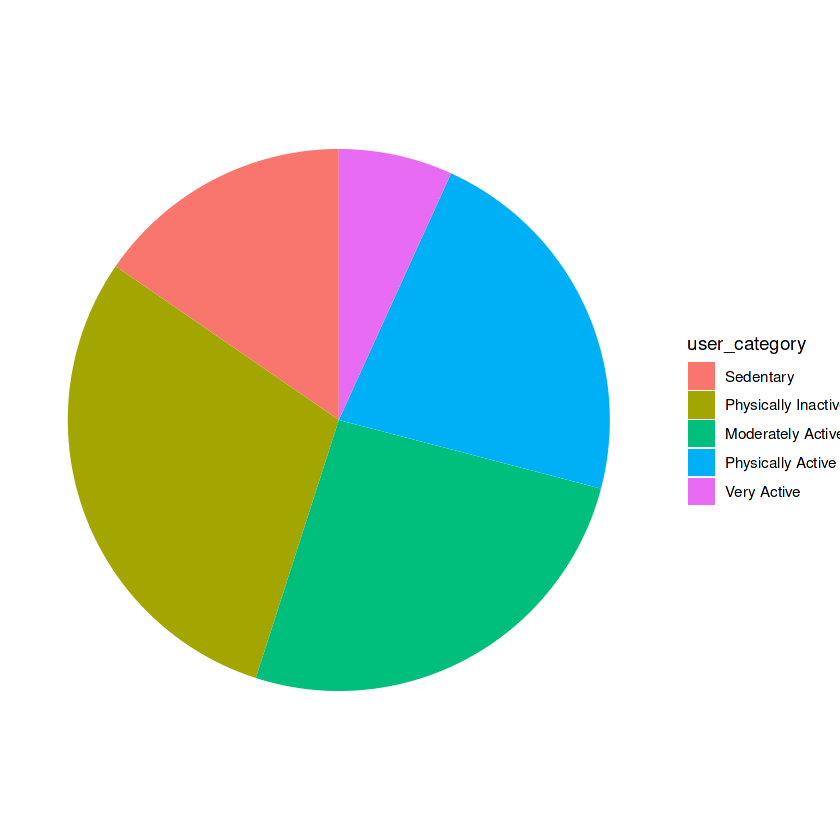

In [99]:
# Plot categories on a pie graph
ggplot(daily_activity, aes(x = "", fill = user_category)) + 
    geom_bar(width = 1) +
    coord_polar("y", start = 0) +
    theme_void()

`geom_smooth()` using formula = 'y ~ x'


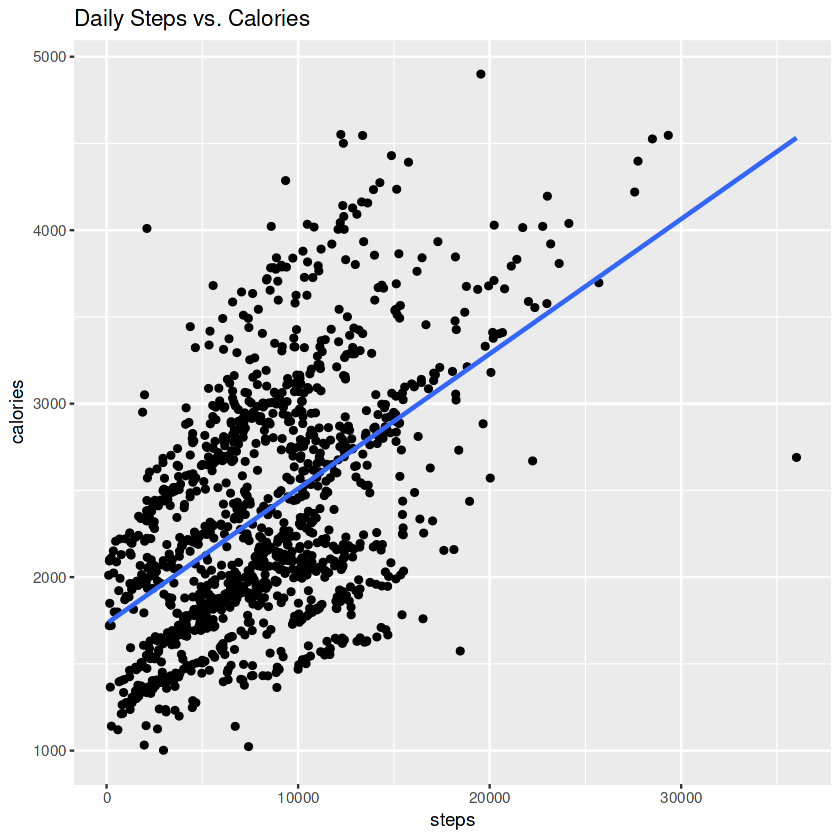

In [100]:
# Plot total steps vs. calories
ggplot(daily_activity, aes(x = steps, y = calories)) + 
  geom_point() +
  geom_smooth(method = lm, se = FALSE) +
  labs(title="Daily Steps vs. Calories")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 814 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 814 rows containing missing values or values outside the scale range
(`geom_point()`).”


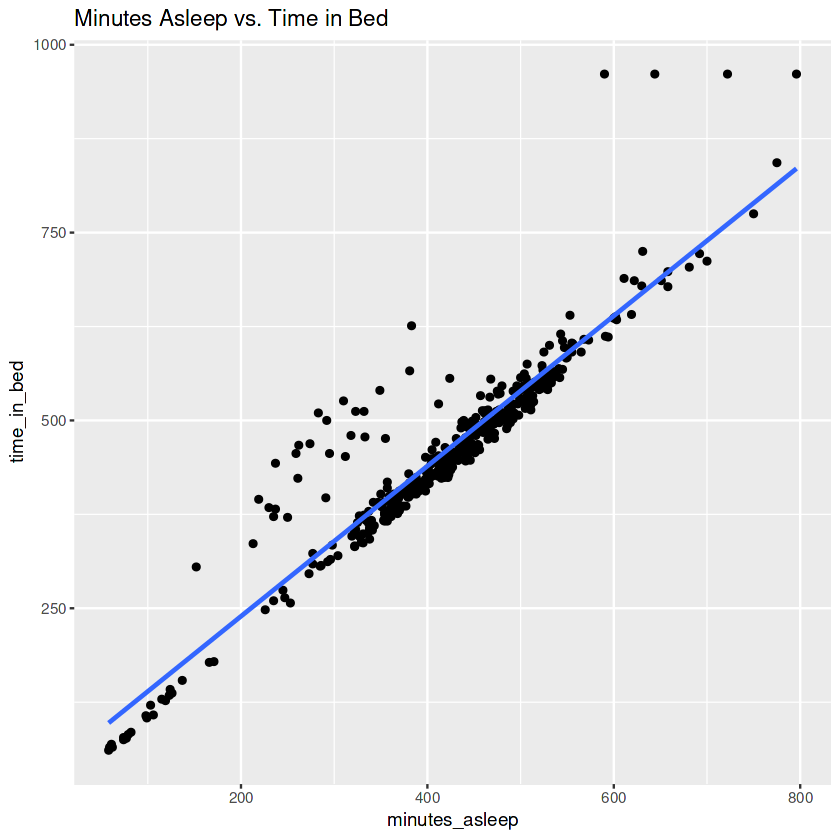

In [101]:
# Plot time asleep vs. total time in bed
ggplot(daily_activity, aes(x = minutes_asleep, y = time_in_bed)) + 
  geom_point() +
  geom_smooth(method = lm, se = FALSE) +
  labs(title="Minutes Asleep vs. Time in Bed")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 814 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 814 rows containing missing values or values outside the scale range
(`geom_point()`).”


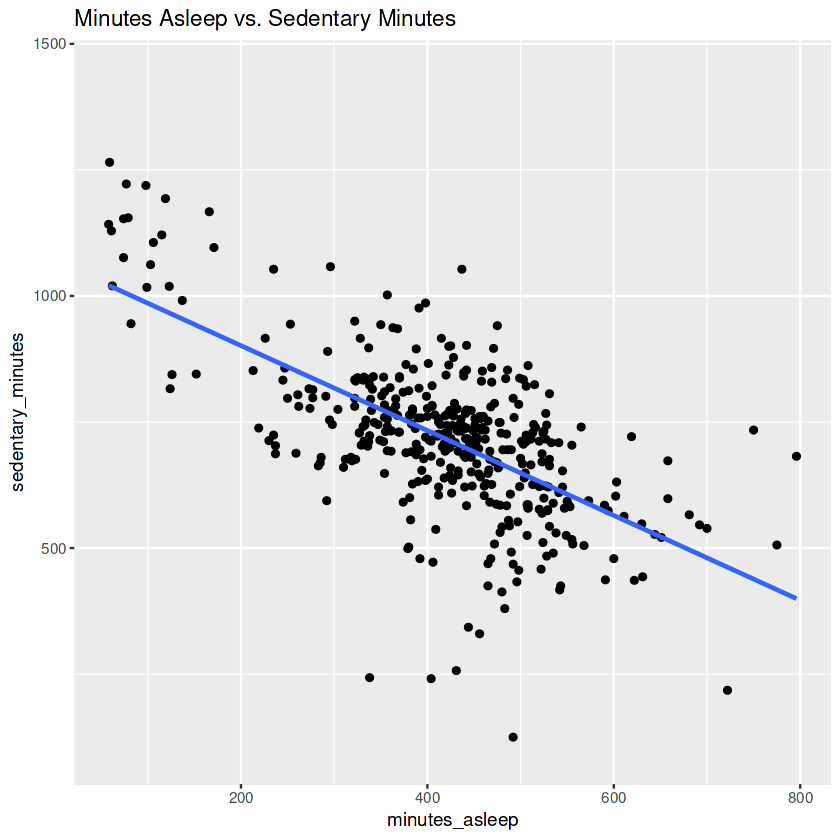

In [102]:
# Plot time asleep vs. sedentary minutes
ggplot(daily_activity, aes(x = minutes_asleep, y = sedentary_minutes)) + 
  geom_point() +
  geom_smooth(method = lm, se = FALSE) +
  labs(title = "Minutes Asleep vs. Sedentary Minutes")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 814 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 814 rows containing missing values or values outside the scale range
(`geom_point()`).”


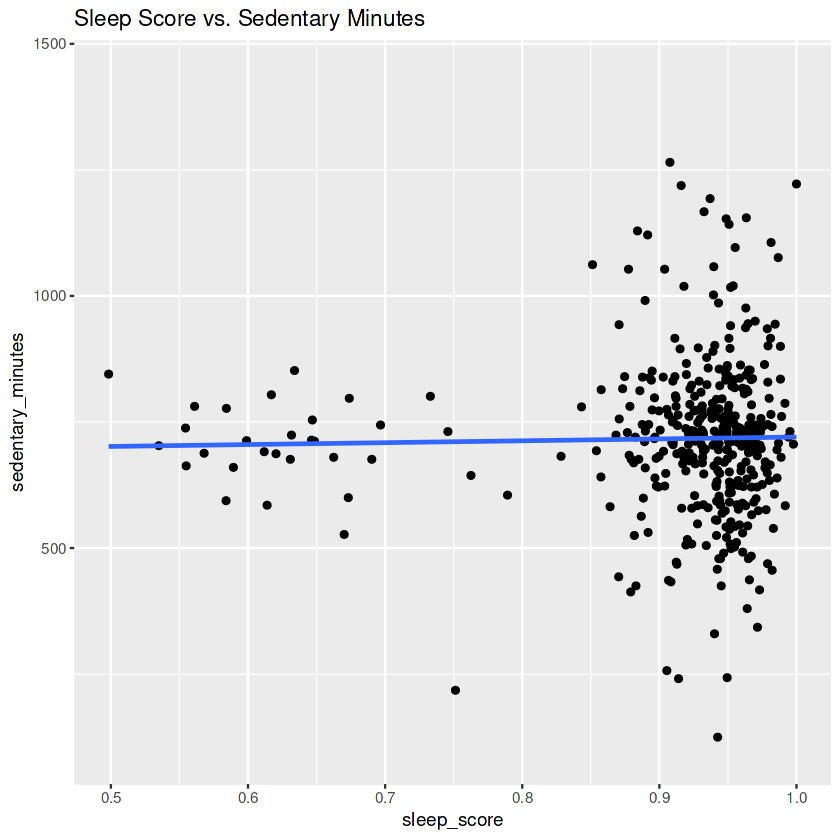

In [103]:
# In order to control for time in bed, we check the relationship between sleep score and sedentary minutes
ggplot(daily_activity, aes(x = sleep_score, y = sedentary_minutes)) + 
  geom_point() +
  geom_smooth(method = lm, se = FALSE) +
  labs(title = "Sleep Score vs. Sedentary Minutes")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 814 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 814 rows containing missing values or values outside the scale range
(`geom_point()`).”


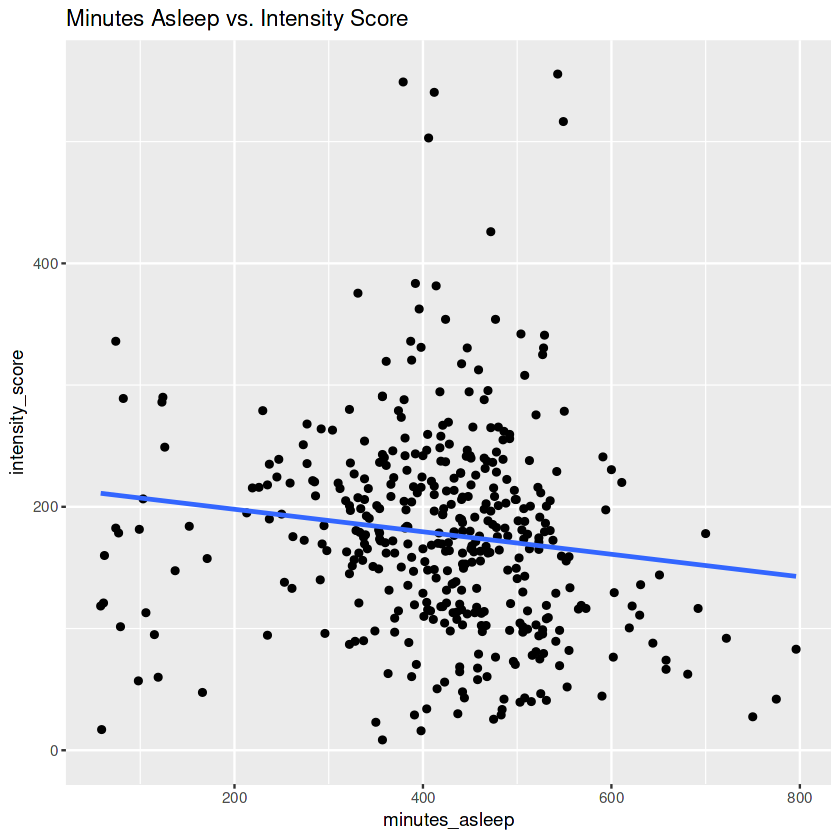

In [104]:
# And then to confirm once more, we'll check minutes asleep vs. intensity score
ggplot(daily_activity, aes(x = minutes_asleep, y = intensity_score)) + 
  geom_point() +
  geom_smooth(method = lm, se = FALSE) +
  labs(title = "Minutes Asleep vs. Intensity Score")

### Average Data vs. Weekday

Warning message in geom_histogram(stat = "identity", fill = "skyblue"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(stat = "identity", fill = "skyblue"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


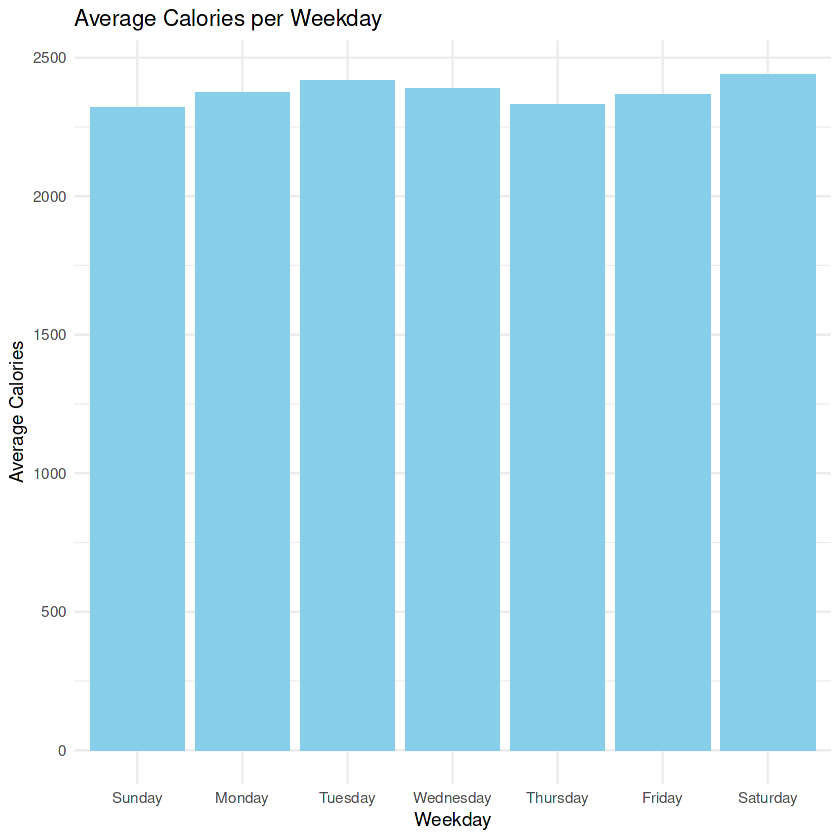

Warning message in geom_histogram(stat = "identity", fill = "skyblue"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


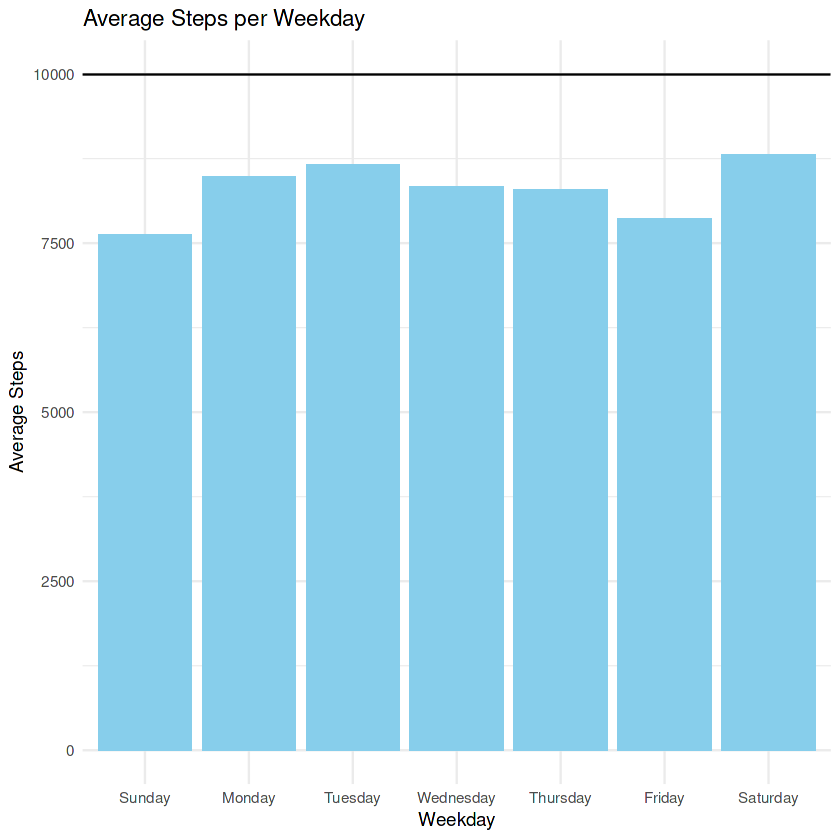

Warning message in geom_histogram(stat = "identity", fill = "skyblue"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


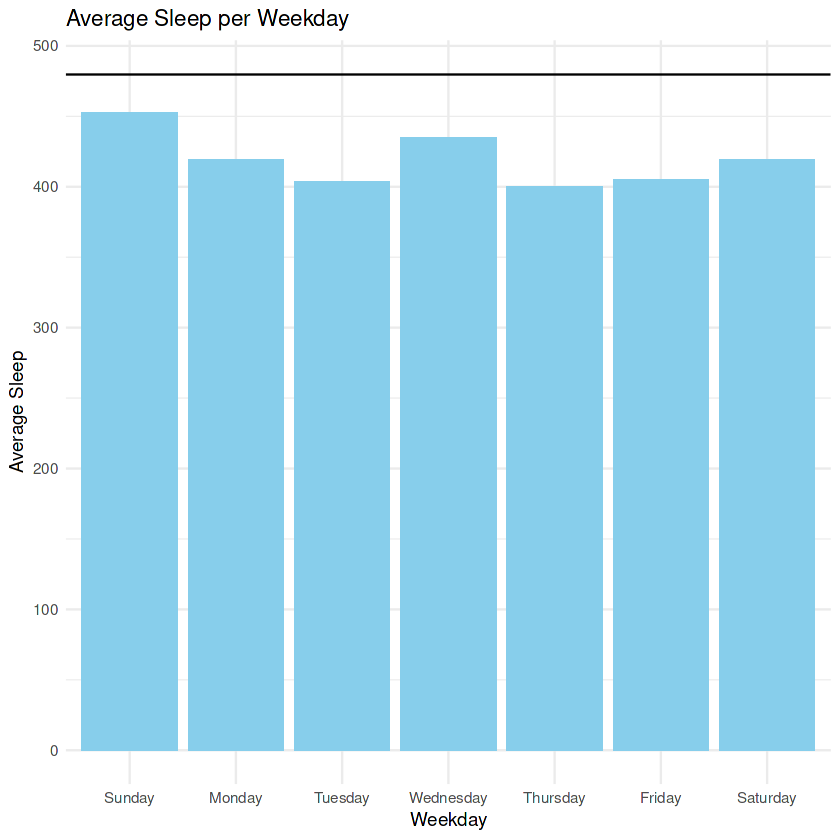

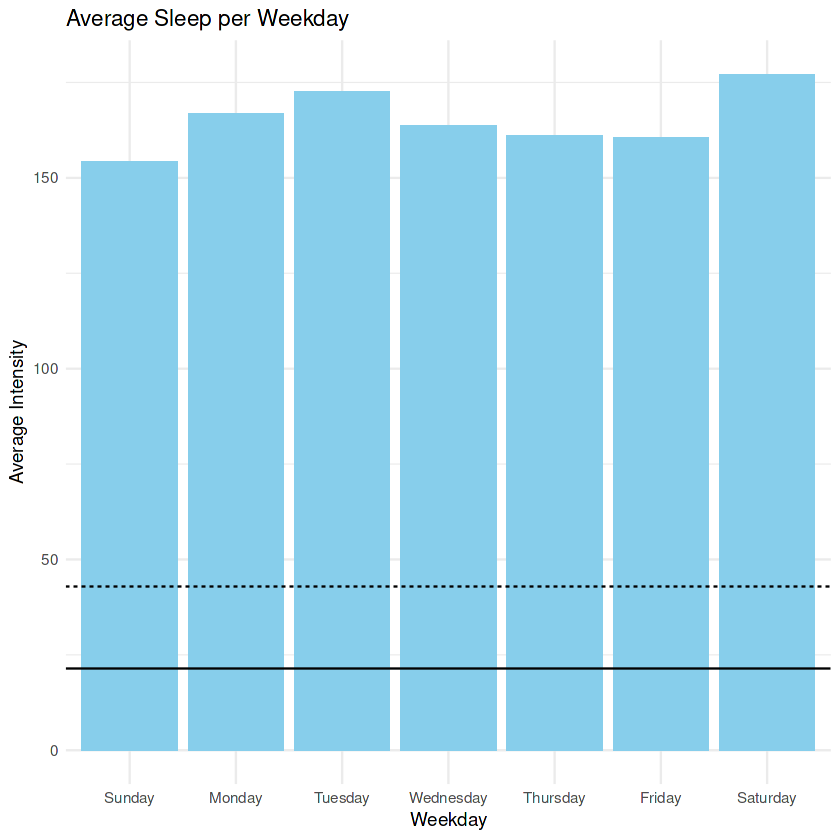

In [105]:
# Calories burned per day
ggplot(weekday_avgs, aes(x = weekday, y = calories)) + 
  geom_histogram(stat = "identity", fill = "skyblue") +
  theme_minimal() +
  labs(title = "Average Calories per Weekday",
       x = "Weekday",
       y = "Average Calories")

# Steps per day
ggplot(weekday_avgs, aes(x = weekday, y = steps)) +
  geom_histogram(stat = "identity", fill = "skyblue") +
  geom_hline(yintercept = 10000) + # recommended steps
  theme_minimal() +
  labs(title = "Average Steps per Weekday",
       x = "Weekday",
       y = "Average Steps")

# Hours slept per day
ggplot(weekday_avgs, aes(x = weekday, y = minutes_asleep)) + 
  geom_histogram(stat = "identity", fill = "skyblue") +
  geom_hline(yintercept = 480) + # recommended sleep
  theme_minimal() +
  labs(title = "Average Sleep per Weekday",
       x = "Weekday",
       y = "Average Sleep")

# Intensity per day
ggplot(weekday_avgs, aes(x = weekday, y = intensity_score)) + 
  geom_histogram(stat = "identity", fill = "skyblue") +
  geom_hline(yintercept = 150/7) + # recommended intensity
  geom_hline(yintercept = 300/7, linetype = "dashed") + # very active
  theme_minimal() +
  labs(title = "Average Sleep per Weekday",
       x = "Weekday",
       y = "Average Intensity")

We can see that none of the averages quite reach the recommended 10000 steps or 480 minutes of sleep per day, yet the daily recommendation of ~22 minutes of intense minutes is easily cleared on each weekday. Even the above-and-beyond recommendation of ~44 minutes per day, is about a third of what each user averages per day. This tells us that either the recommendation is too low or FitBit defines active minutes differently than the American Heart Association.

### Data vs. Hour

Warning message in geom_histogram(stat = "identity", fill = "skyblue"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(stat = "identity", fill = "skyblue"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


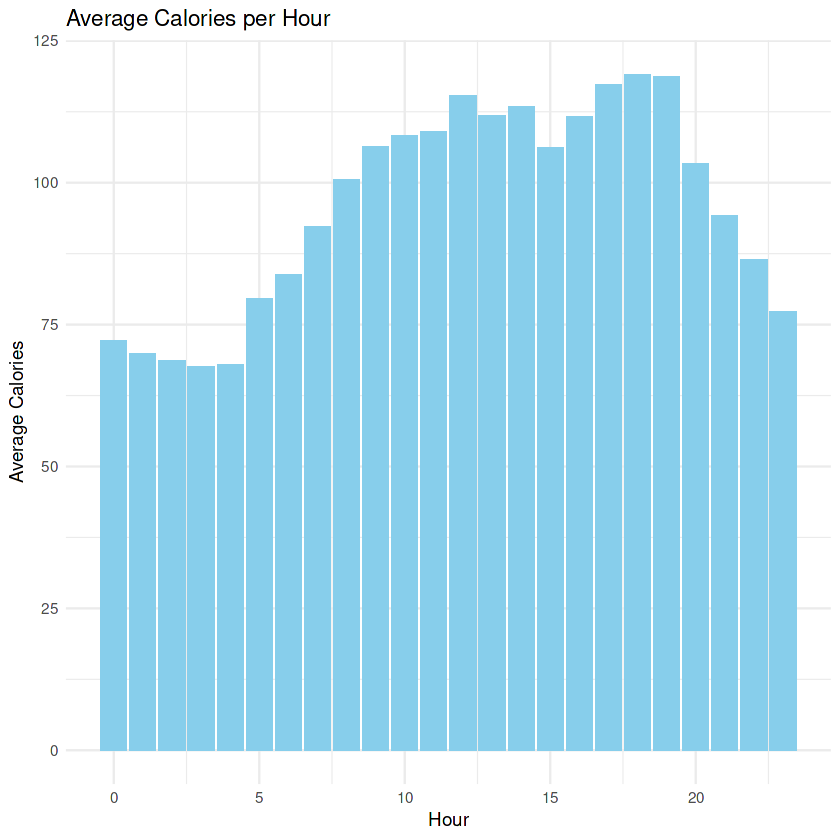

Warning message in geom_histogram(stat = "identity", fill = "skyblue"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


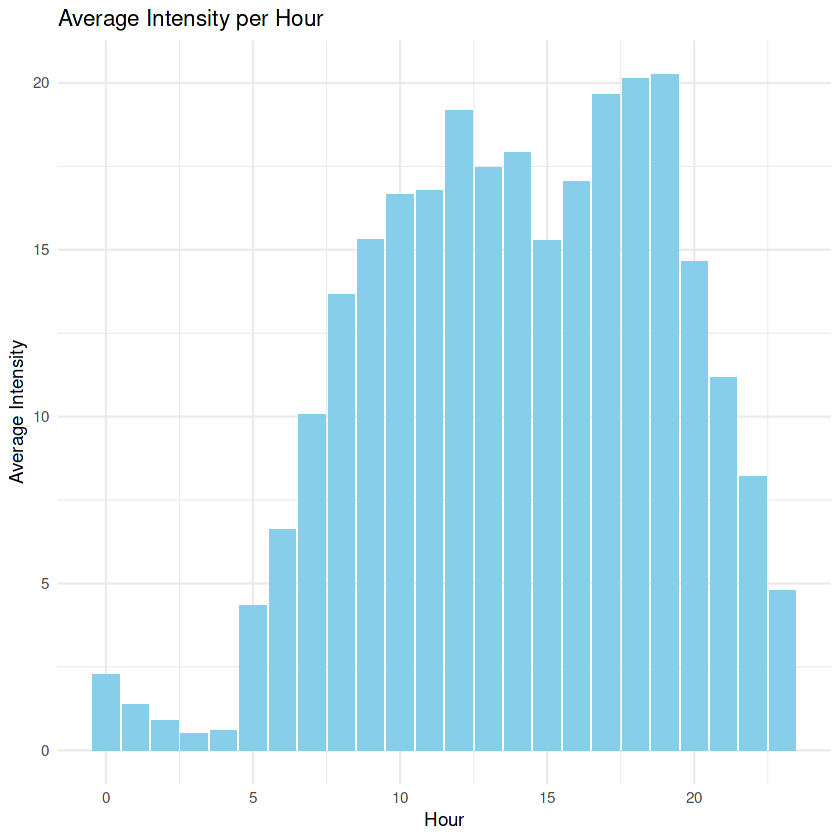

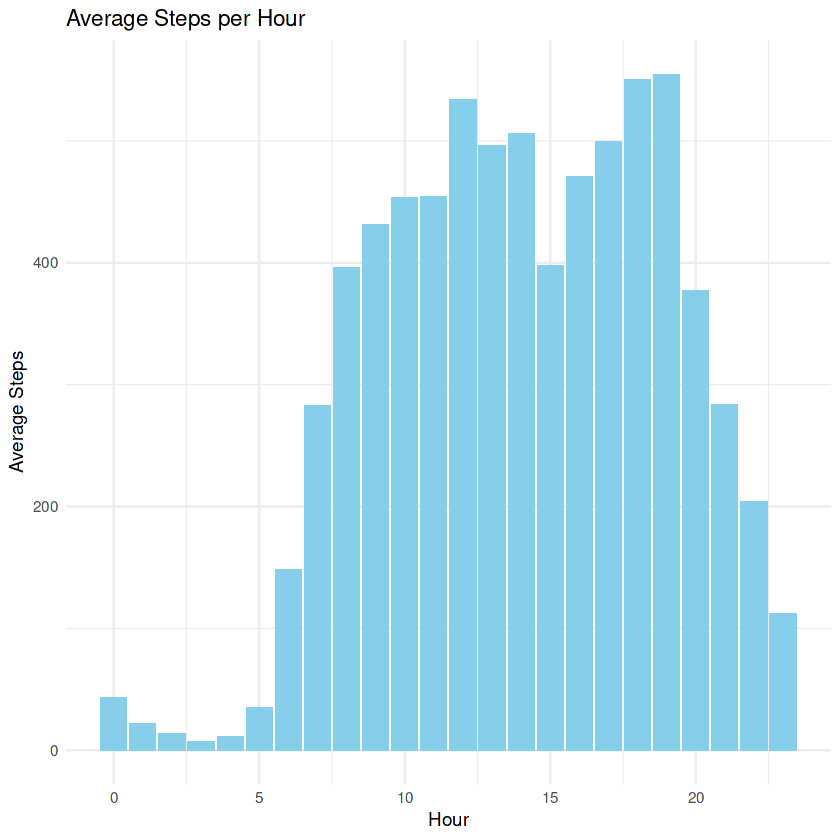

In [106]:
# Calories per hour
ggplot(hourly_avgs, aes(x = hour, y = calories)) +
  geom_histogram(stat = "identity", fill = "skyblue") +
  theme_minimal() +
  labs(title = "Average Calories per Hour",
       x = "Hour",
       y = "Average Calories")

# Intensity per hour
ggplot(hourly_avgs, aes(x = hour, y = intensity)) + 
  geom_histogram(stat = "identity", fill = "skyblue") +
  theme_minimal() + 
  labs(title = "Average Intensity per Hour",
       x = "Hour",
       y = "Average Intensity")

# Steps per hour
ggplot(hourly_avgs, aes(x = hour, y = steps)) + 
  geom_histogram(stat = "identity", fill = "skyblue") +
  theme_minimal() + 
  labs(title = "Average Steps per Hour",
       x = "Hour",
       y = "Average Steps")

* All three metrics reach their minimums overnight, but while intensity and steps bottom out near zero, calories still remains at a moderate level.
 * Our bodies obviously don't take steps or perform activity while we sleep overnight, but they do maintain a basal metabolic rate of calorie burn even when we're sleeping.
* Users are most active immediately around 6pm and 7pm (after work).
* The second most active time of day is the early afternoon (lunch time).
 * We can infer that most of the users work full-time jobs.

### We can plot multiple columns against time by pivoting our data to long format. The variation between weekdays wasn't as pronounced as between hours, so let's try it with our hourly average data.

,steps,calories,intensity
steps,1.0000000,0.9924138,0.9948438
calories,0.9924138,1.0000000,0.9989693
intensity,0.9948438,0.9989693,1.0000000


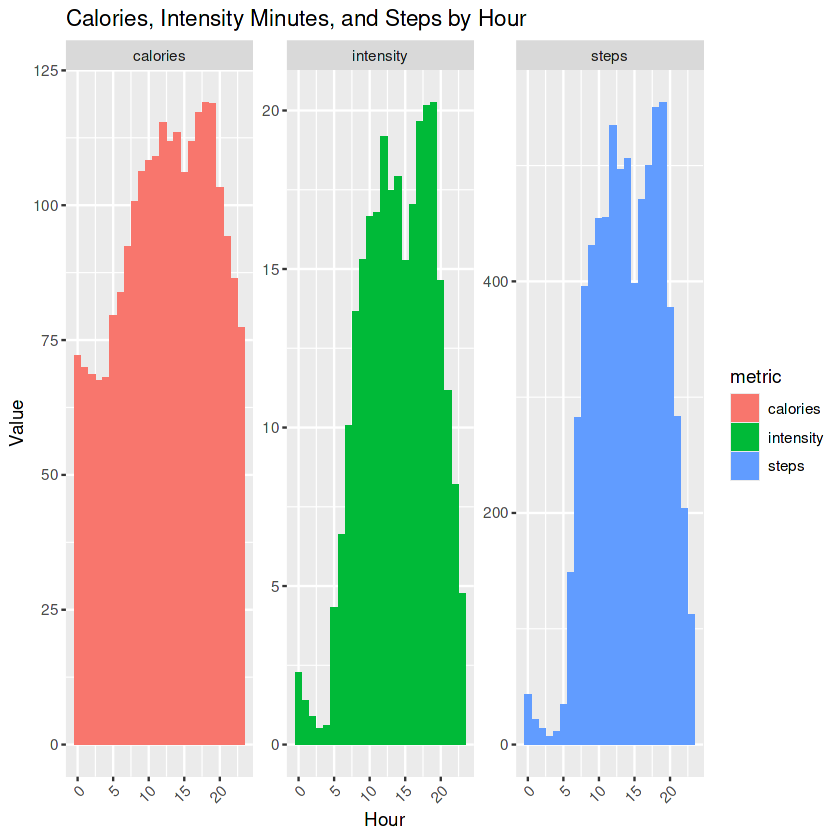

In [107]:
# Pivot to long data
hourly_avgs_long <- pivot_longer(hourly_avgs,
                                 cols = c(calories, steps, intensity),
                                 names_to = "metric",
                                 values_to = "value")

# Plot 
ggplot(hourly_avgs_long, aes(x = hour, y = value, fill = metric)) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_wrap(~ metric, scales = "free") +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) + 
  labs(title = "Calories, Intensity Minutes, and Steps by Hour", x = "Hour", y = "Value")

# Confirm correlations
cor(hourly_avgs[, .(steps, calories, intensity)])

We can clearly see an almost perfect correlation between all 3, with values lowest in the early morning, rising steadily towards midday, with an early evening spike. Calories remain relatively higher overnight because we continue to burn calories while we sleep whereas steps and intensity should be minimal.

### Next we'll plot the different activity intensity levels against calories using the same pivoting method.

`geom_smooth()` using formula = 'y ~ x'


,calories,lightly_active_minutes,fairly_active_minutes,very_active_minutes
calories,1.0000000,0.13806884,0.28758920,0.58634050
lightly_active_minutes,0.1380688,1.00000000,0.06412997,-0.04098602
fairly_active_minutes,0.2875892,0.06412997,1.00000000,0.28572058
very_active_minutes,0.5863405,-0.04098602,0.28572058,1.00000000


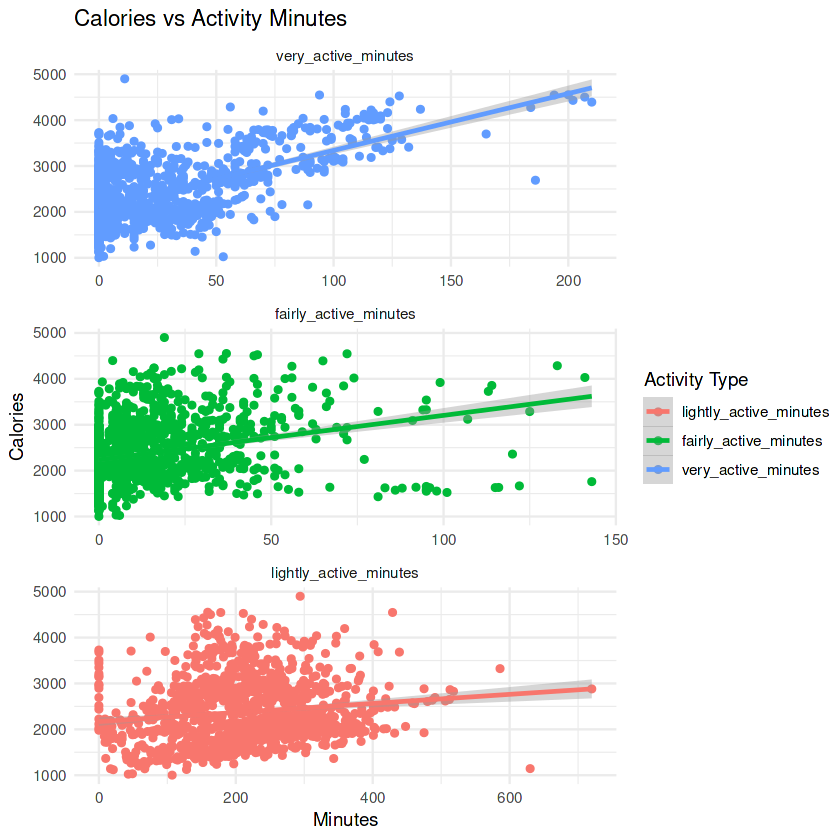

In [108]:
# Reshape the data from wide to long format
daily_activity_intensity_long <- pivot_longer(daily_activity,
                                     cols = c(lightly_active_minutes, fairly_active_minutes, very_active_minutes),
                                     names_to = "activity_type",
                                     values_to = "minutes")

# Make sure the intensity levels are ordered correctly
daily_activity_intensity_long$activity_type <- factor(daily_activity_intensity_long$activity_type, levels = c("lightly_active_minutes", "fairly_active_minutes", "very_active_minutes"))

# Create the plot
ggplot(daily_activity_intensity_long, aes(x = minutes, y = calories, color = activity_type)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE) +
  facet_wrap(~ factor(activity_type, levels = c("very_active_minutes", "fairly_active_minutes", "lightly_active_minutes")), scales = "free_x", ncol = 1) +
  labs(title = "Calories vs Activity Minutes",
       x = "Minutes",
       y = "Calories",
       color = "Activity Type") +
  theme_minimal()

# Calculate correlations
cor(daily_activity[, .(calories, lightly_active_minutes, fairly_active_minutes, very_active_minutes)], use = "complete.obs")

We can that all active minutes are positively correlated with calories, with correlations strengthening as the intensity of thoe minutes increases.

## Export Data
### We can visualize multiple plots even more powerfully with Tableau, so let's write our data to csv files and transfer them to Tableau.

In [109]:
#Export to CSV
write.csv(daily_activity, file = 'fitbit_daily_activity_03122016_05122016.csv')
write.csv(hourly_activity, file = 'fitbit_hourly_activity_03122016_05122016.csv')
write.csv(daily_activity_intensity_long, file = 'fitbit_daily_activity_intensity_long_03122016_05122016.csv')

# 6. Act

### Tableau Dashboards
Now that we've migrated our data to Tableau, we can create cleaner and more descriptive visualizations.

## [User Categories](https://public.tableau.com/views/BellabeatCaseStudy-UserCategories/UserCategories?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

Our first dashboard is a breakdown of our User Categories that visualizes the data by user type:

<div class='tableauPlaceholder' id='viz1729791998047' style='position: relative'><noscript><a href='#'><img alt='User Categories ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Be&#47;BellabeatCaseStudy-UserCategories&#47;UserCategories&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='BellabeatCaseStudy-UserCategories&#47;UserCategories' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Be&#47;BellabeatCaseStudy-UserCategories&#47;UserCategories&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1729791998047');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1366px';vizElement.style.height='795px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1366px';vizElement.style.height='795px';} else { vizElement.style.width='100%';vizElement.style.height='1227px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>


* We can see that the users are fairly spread out amongst the categories (Tudor-Locke and Bassett classification system), aside from the 2 users in the 'Very Active' category.
* We've replotted a couple of graphs that we plotted using R, but now we we've colored each data point based on that user's category.
 * Since the categories are based on steps, we'd expect the colors to dark as steps increase, but we can also see clearly defined areas of the graph along the Calories and Intensity Score axes.
 * The R-Squared value of Intensity Score vs. Calories is ~.39 while Steps vs. Calories is ~.29, so increasing intensity score is more beneficial than taking more steps.
* Unsurprisingly, there is a steady increase in steps and intensity score as the user category level increases, but there are also some interesting measures.
 * The Moderately Active group burned more calories on average the the Physically Active group.
  * This might give us some insight into why the Moderately Active group burned more calories on average. The Very Active Minutes may be the key to higher calorie burn.
 * The Very Active group has some of the least lightly and fairly active minutes, while having more than double the very active minutes as any other group.

## [Intensity Breakdown](https://public.tableau.com/views/BellabeatCaseStudy-IntensityBreakdown/IntensityBreakdown?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

Our next dashboard is a side-by-side look at the relationship between the intensity level of active minutes and calories, similar to the one we plotted with R, but this time adding steps.

<div class='tableauPlaceholder' id='viz1729792836209' style='position: relative'><noscript><a href='#'><img alt='Intensity Breakdown ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Be&#47;BellabeatCaseStudy-IntensityBreakdown&#47;IntensityBreakdown&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='BellabeatCaseStudy-IntensityBreakdown&#47;IntensityBreakdown' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Be&#47;BellabeatCaseStudy-IntensityBreakdown&#47;IntensityBreakdown&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1729792836209');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1366px';vizElement.style.height='795px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1366px';vizElement.style.height='795px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

* In all cases, we can see that an increase in any active minutes is associated with an increase in calories and steps.
* What's interesting is that we can see the correlation (trend line) between active minutes and calories/steps increase as the intensity of those active minutes increases.
 * This further supports that observation that the Moderately Active group burned more calories on average than the higher intensity Physically Active group because they had more very active minutes.

## [Averages by Day/Time](https://public.tableau.com/views/BellabeatCaseStudy-AveragesbyDayTime/AveragesbyDayTime?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

Next we can look at our average data grouped by day of the week and time instead of user category. These plots were also already done using R, but are now presented with easier to read labels, color coding, annotations, and general formatting. The most interesting difference from our R generated plots is the separation of weekday and weekend plots.

<div class='tableauPlaceholder' id='viz1729792814664' style='position: relative'><noscript><a href='#'><img alt='Averages by Day&#47;Time ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Be&#47;BellabeatCaseStudy-AveragesbyDayTime&#47;AveragesbyDayTime&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='BellabeatCaseStudy-AveragesbyDayTime&#47;AveragesbyDayTime' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Be&#47;BellabeatCaseStudy-AveragesbyDayTime&#47;AveragesbyDayTime&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1729792814664');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1366px';vizElement.style.height='795px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1366px';vizElement.style.height='795px';} else { vizElement.style.width='100%';vizElement.style.height='1977px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

* Our Weekdays plot looks a lot similar to our hourly averages plot, which makes sense given that there are only 2 weekend days and 5 weekday days.
* There is still a peak from 5pm to 7pm indicating a preference for post work rather than pre work exercise.
* Our Weekends plot shows a much more gradual increase in activity until a 2pm peak.
* While activity very gently and gradually declines over the second half of the day on weekends, there is a small spike at 7pm.
 * This might users engaging in evening exercise, keeping with their weekday schedule.
 * It might also be users partaking in the evening activities that generally accompany weekends, like going out.

## [Sleep Data](https://public.tableau.com/views/BellabeatCaseStudy-SleepData/SleepData?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

And last, but not least, we have our sleep data. We'll end with this one remembering that we only had 8 users, so our data isn't the most robust and is highly susceptible to skewing. This dashboard presents the sleep data relative to user category.

<div class='tableauPlaceholder' id='viz1729792844748' style='position: relative'><noscript><a href='#'><img alt='Sleep Data ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Be&#47;BellabeatCaseStudy-SleepData&#47;SleepData&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='BellabeatCaseStudy-SleepData&#47;SleepData' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Be&#47;BellabeatCaseStudy-SleepData&#47;SleepData&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1729792844748');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1366px';vizElement.style.height='795px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1366px';vizElement.style.height='795px';} else { vizElement.style.width='100%';vizElement.style.height='1327px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

* By plotting Steps vs. Sleep Score, I wanted to see if there was any relationship between a user's activity and their sleep, even when separating the user categories. At first it seemed like there was none, until I plotted average sleep scores by user category.
 * There was an extremely small, but steady percentage increase in sleep score going from category to category except for the the Physically Active Category, which had a relatively large decrease.
 * I then color coded the data points on the original plot and realized that there were a large amount of Physically Active data points - they were all from User ID: 3977333714
 * Adding a box plot onto the graph, we can see that all of that user's data points fell well below the lower whisker.
* I decided to replot everything filtering out the outliers.
 * We can see that the averages have leveled out much more gently.
  * The percentage increase is really only significant in the Very Active group, but that group only contains 2 people (and possibly only 1 with sleep data).
 * On the scatter plot we can see some very interesting trends.
  * As the user category increases, so does the R-Squared value (with the exception of the very small Very Active group).
   * It would seem that users who are generally more active are more resilient in their ability to sleep after higher activity days.
   * Sedentary and Physically Inactive users tend to not sleep well after a high step count day whereas Moderately Active and Physically Active users actually sleep a little better. 
   * While the Very Active group sleeps a little worse the more steps they take, they still sleep far better than the other groups.
  * The trend lines of the first four categories all seem to intersect around 3500 steps and a sleep score of 94%.
   * We can't say exactly why from this data alone, but what the data tells us is that if any user (besides a Very Active user) has a 3500 step day, they will also have a 94% sleep score night (and vice versa)
   * We can assume that the steps from the day are more likely to cause the sleep score because they come first, but we also can't conclude that steps affect sleep score in general.

## Conclusion

### As a reminder, the business task was to analyze smart device usage data in order to gain insight into how consumers use non-Bellabeat smart devices, while answering three specific questions:
1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat marketing strategy?

#### 1. What are some trends in smart device usage?

* Users are segmented fairly evenly by activity level
* Users are significantly more active than the average American
* Users work 9-5 jobs
* Users prefer evening exercise
* Higher intensity level is more beneficial than more steps, although the two are strongly correlated anyways
* Saturdays, Mondays, and Tuesdays are the most active days
* Sundays, Thursdays, and Fridays are the least active days
* All users consistently surpass the AHA's daily recommendation of 22 active minutes (and even the above-and-beyond recommendation of 43) by a large amount
* Users who were generally less active had their sleep negatively affected by sporadic, high activity days
* The inverse is also true, where users who were generally more active slept better after high activity days
* The strongest indicator of more time asleep was more time in bed

#### 2. How could these trends apply to Bellabeat customers?

Bellabeat customers could benefit from the following:
* Dynamic goals rather than static ones - Sundays are low activity days, so the Bellabeat app could recommend a step or active minute goal based on the user's Sunday average steps or active minutes
* Gamified Intensity Score - Presenting the idea of Very Active Minutes being more "valuable" than Fairly or Lightly Active Minutes
* Bedtime Reminders - If users want to sleep more, the best way to do that is to go to bed earlier
* Daily Recaps - A nightly summary of the day's activity, which can also provide recommendations for sleep duration or activity level for the following day(s)

#### 3. How could these trends help influence Bellabeat marketing strategy?

We know that Bellabeat's mission is to use "beautifully designed [wellness] technology to inform and inspire women." Based on that information, we can narrow our target demographic to women who might not have high level knowledge of their own health, but value insightful information and most importantly, want to use that information to improve their own health.
* We know that FitBit users are probably full time employees, who prefer to exercise after work, so one strategy we could employ would be to target potential customers during the post work commute. Whether that's traditional advertising on high traffic roads or in public transportation spaces, we could present Bellabeat products as a way to take control of their health after a long day of sedentary work.
* Bellabeat focuses more on digital marketing, investing in Google Search, so we could target potential customers who search for more basic health questions like "how do I lose weight?" or "how many steps should I take?" These questions are indicative of a population that wants to improve their health, but maybe don't know where to start. Bellabeat is there to get them started.
* Knowing that users exercise a lot on Mondays and Tuesdays, but far less for the rest of the work week, we can narrow our digital marketing to Wednesdays to inspire potential customers to continue their strong start, using Bellabeat products as inspirational tools.

### Thanks for taking the time to read all of this! If you've made it this far, you might be:
* considering me for an open position (thank you again for your time and consideration)
* my mom, incredibly proud of her son's work (whether it be macaroni art or data analysis)
* super interested in FitBit data and/or data cleaning! (cool!)